# 5. 세분화 성능 — 4구조별 · 기초자산별

통합 모델 하나로 4구조(STEP/LIZARD × 낙인/노낙인)를 모두 커버한다. 전체 R² 만 보면
STEP-낙인이 표본의 약 39%를 차지해 다른 구조의 열화가 가려지므로, **구조별·기초자산별로 쪼개서**
그림으로 확인한다.

- **구조별**: 지표 3종 그룹바 · 예측 산점 2×2 · 오차 분포
- **기초자산별**: 바스켓 조합별 · **개별 지수 포함 여부별** · 지수 × 구조 히트맵
- **시기별**: 구조 × walk-forward 폴드 (시간 안정성)

저장물: `result/image/seg_*.png` (dpi 400·투명·16:9), `result/statistics/seg_*.csv`.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from util import utils, file_manager as fm, plot as _plot
from util.metric import metrics, metrics_by
from module import data, infer

FACE = 10000
cfg = utils.load_config()
D = data.load(cfg)
preds = infer.predict_all_from_weights(D, cfg)

# 구조·기초자산 식별자 (모델 입력이 아니라 평가 분해용)
src = pd.read_parquet(fm.source())[["item", "opt_type", "ki_yn", "udl1", "udl2", "udl3", "udl_key"]].copy()
src["struct"] = src["opt_type"] + " x " + np.where(src["ki_yn"] == 1, "KI", "no-KI")
src = src.rename(columns={"item": "ITEM_CD"}).astype({"ITEM_CD": str}).set_index("ITEM_CD")

fold = np.full(D.n, -1, dtype=int)
for k, (_tr, _va, te) in enumerate(D.WF):
    fold[te] = k
finfo = pd.DataFrame({"ITEM_CD": D.ITEM.astype(str), "fold": fold}).set_index("ITEM_CD")

MODELS = [m for m in ["deeponet_hybrid", "deeponet_hybrid_mape", "deeponet_hybrid_l1",
                      "xgb_hybrid", "bench_xgboost"] if m in preds]
BEST = MODELS[0]

def tidy(name):
    d = preds[name].copy()
    d["ITEM_CD"] = d["ITEM_CD"].astype(str)
    d = d.join(src, on="ITEM_CD").join(finfo, on="ITEM_CD")
    d["err"] = d["y_pred"] - d["y_true"]
    d["ape"] = (d["err"].abs() / d["y_true"].abs()) * 100
    d["model"] = name
    return d

M = pd.concat([tidy(m) for m in MODELS], ignore_index=True)
assert M["struct"].notna().all(), "parquet 조인 실패 (ITEM_CD 불일치)"
STRUCTS = ["STEP x KI", "STEP x no-KI", "LIZARD x KI", "LIZARD x no-KI"]
STRUCTS = [s for s in STRUCTS if s in set(M["struct"])]
print(f"모델 {len(MODELS)} | OOS {len(preds[BEST]):,}행 | 대표 모델 {BEST}")
print(M.groupby("struct")["ITEM_CD"].nunique().to_string())

모델 5 | OOS 23,516행 | 대표 모델 deeponet_hybrid
struct
LIZARD x KI         655
LIZARD x no-KI     1858
STEP x KI          8708
STEP x no-KI      12295


## 5-1. 구조별 성능

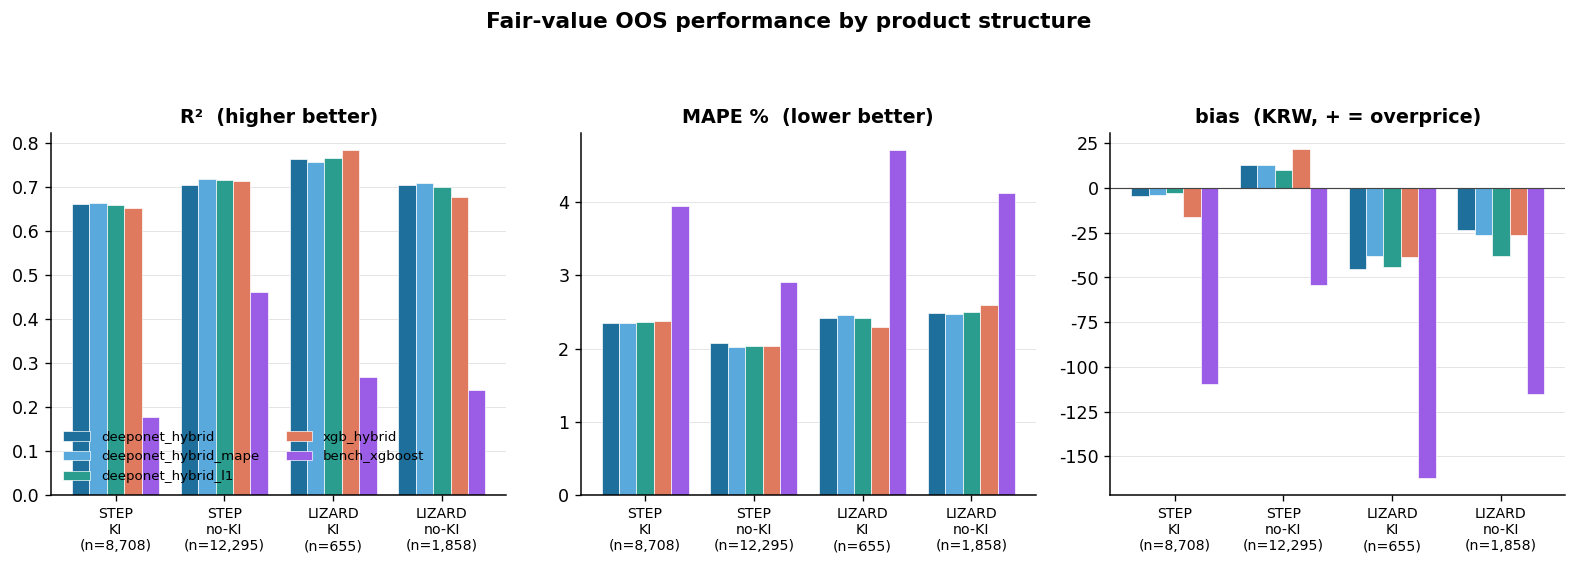

               model         struct     n     R2   MAPE     BiasKRW
     deeponet_hybrid      STEP x KI  8708 0.6610 2.3549   -4.403300
     deeponet_hybrid   STEP x no-KI 12295 0.7041 2.0764   12.666800
     deeponet_hybrid    LIZARD x KI   655 0.7632 2.4210  -45.343700
     deeponet_hybrid LIZARD x no-KI  1858 0.7047 2.4920  -23.446400
deeponet_hybrid_mape      STEP x KI  8708 0.6646 2.3461   -3.953400
deeponet_hybrid_mape   STEP x no-KI 12295 0.7184 2.0236   12.818000
deeponet_hybrid_mape    LIZARD x KI   655 0.7572 2.4581  -37.852001
deeponet_hybrid_mape LIZARD x no-KI  1858 0.7086 2.4706  -26.199600
  deeponet_hybrid_l1      STEP x KI  8708 0.6600 2.3575   -2.557800
  deeponet_hybrid_l1   STEP x no-KI 12295 0.7169 2.0387    9.825500
  deeponet_hybrid_l1    LIZARD x KI   655 0.7667 2.4208  -44.277401
  deeponet_hybrid_l1 LIZARD x no-KI  1858 0.7006 2.5054  -37.943401
          xgb_hybrid      STEP x KI  8708 0.6522 2.3705  -16.471100
          xgb_hybrid   STEP x no-KI 12295 0.7135

In [2]:
# 그림 1: 구조별 R² · MAPE% · Bias(원) — 모델 그룹바
from sklearn.metrics import r2_score

rows = []
for name in MODELS:
    d = M[M.model == name]
    for s in STRUCTS:
        g = d[d.struct == s]
        rows.append(dict(model=name, struct=s, n=len(g), R2=r2_score(g.y_true, g.y_pred),
                         MAPE=g.ape.mean(), BiasKRW=g.err.mean() * FACE))
S = pd.DataFrame(rows)
S.to_csv(fm.stat("seg_structure"), index=False)

fig, ax = plt.subplots(1, 3, figsize=(_plot.SLIDE_W, 4.8))
x = np.arange(len(STRUCTS)); w = 0.8 / len(MODELS)
for j, name in enumerate(MODELS):
    v = S[S.model == name].set_index("struct").loc[STRUCTS]
    off = (j - (len(MODELS) - 1) / 2) * w
    c = _plot._QUAL[j % len(_plot._QUAL)]
    for a, col, lab in zip(ax, ["R2", "MAPE", "BiasKRW"],
                           ["R²", "MAPE %", "bias (KRW / 10,000 face)"]):
        a.bar(x + off, v[col].values, w, label=name, color=c, edgecolor="white", linewidth=0.4)
for a, lab in zip(ax, ["R²  (higher better)", "MAPE %  (lower better)",
                       "bias  (KRW, + = overprice)"]):
    a.set_xticks(x)
    a.set_xticklabels([s.replace(" x ", "\n") + f"\n(n={int(S[S.struct==s].n.iloc[0]):,})" for s in STRUCTS],
                      fontsize=8.5)
    a.set_title(lab, fontsize=11.5)
    a.axhline(0, color="#444", lw=0.7)
    a.grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5)
ax[0].legend(fontsize=8, ncol=2, loc="lower left")
fig.suptitle("Fair-value OOS performance by product structure", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(fm.image("seg_structure_metrics"))
plt.show()
print(S.round(4).to_string(index=False))
print("saved ->", fm.image("seg_structure_metrics").name, "|", fm.stat("seg_structure").name)

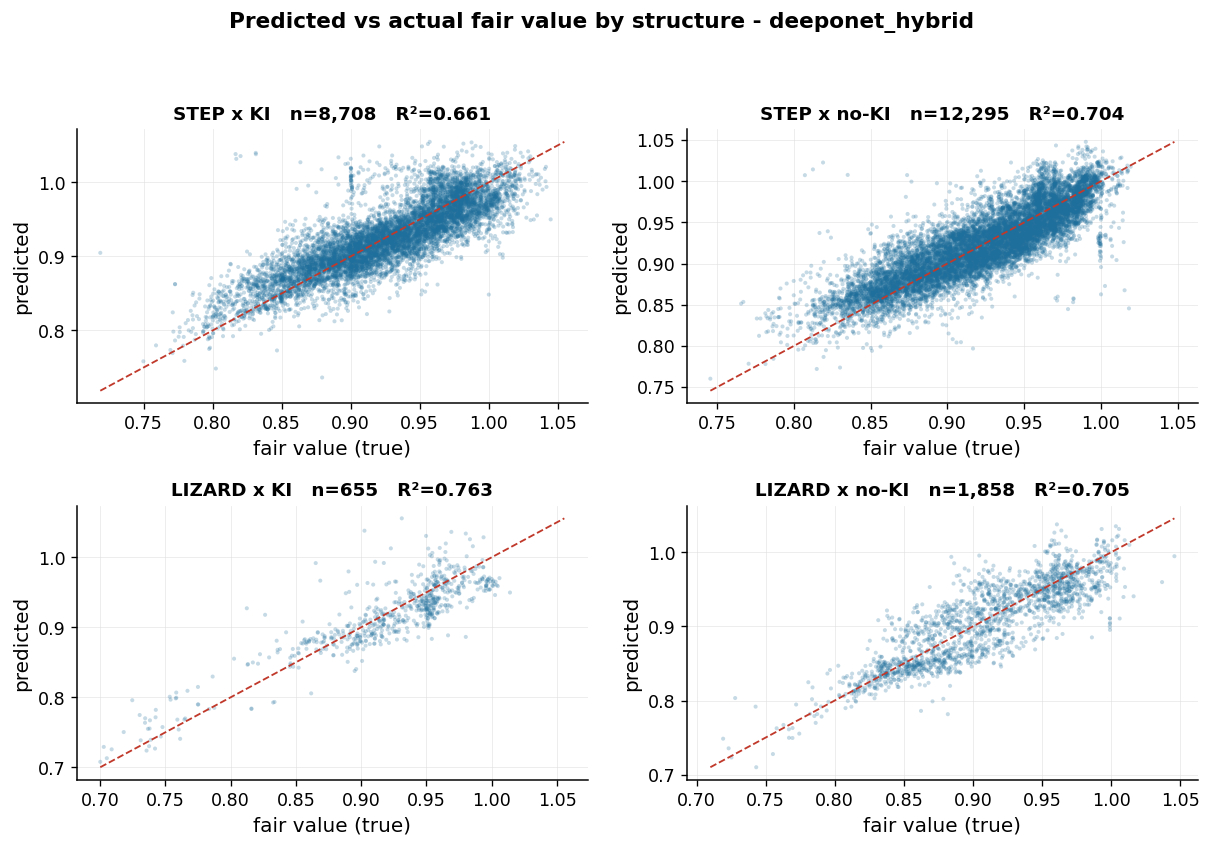

saved -> seg_structure_scatter.png


In [3]:
# 그림 2: 구조별 예측 vs 실제 산점 (대표 모델)
d = M[M.model == BEST]
fig, axs = plt.subplots(2, 2, figsize=(_plot.SLIDE_W * 0.78, 7.2))
for a, s in zip(axs.ravel(), STRUCTS):
    g = d[d.struct == s]
    lim = [min(g.y_true.min(), g.y_pred.min()), max(g.y_true.max(), g.y_pred.max())]
    a.scatter(g.y_true, g.y_pred, s=6, alpha=0.25, color="#1f6f9c", edgecolors="none")
    a.plot(lim, lim, "--", color="#c0392b", lw=1.1)
    a.set_title(f"{s}   n={len(g):,}   R²={r2_score(g.y_true, g.y_pred):.3f}", fontsize=11)
    a.set_xlabel("fair value (true)"); a.set_ylabel("predicted")
    a.grid(color="#dddddd", lw=0.5, alpha=0.6)
for a in axs.ravel()[len(STRUCTS):]:
    a.axis("off")
fig.suptitle(f"Predicted vs actual fair value by structure - {BEST}", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(fm.image("seg_structure_scatter"))
plt.show()
print("saved ->", fm.image("seg_structure_scatter").name)

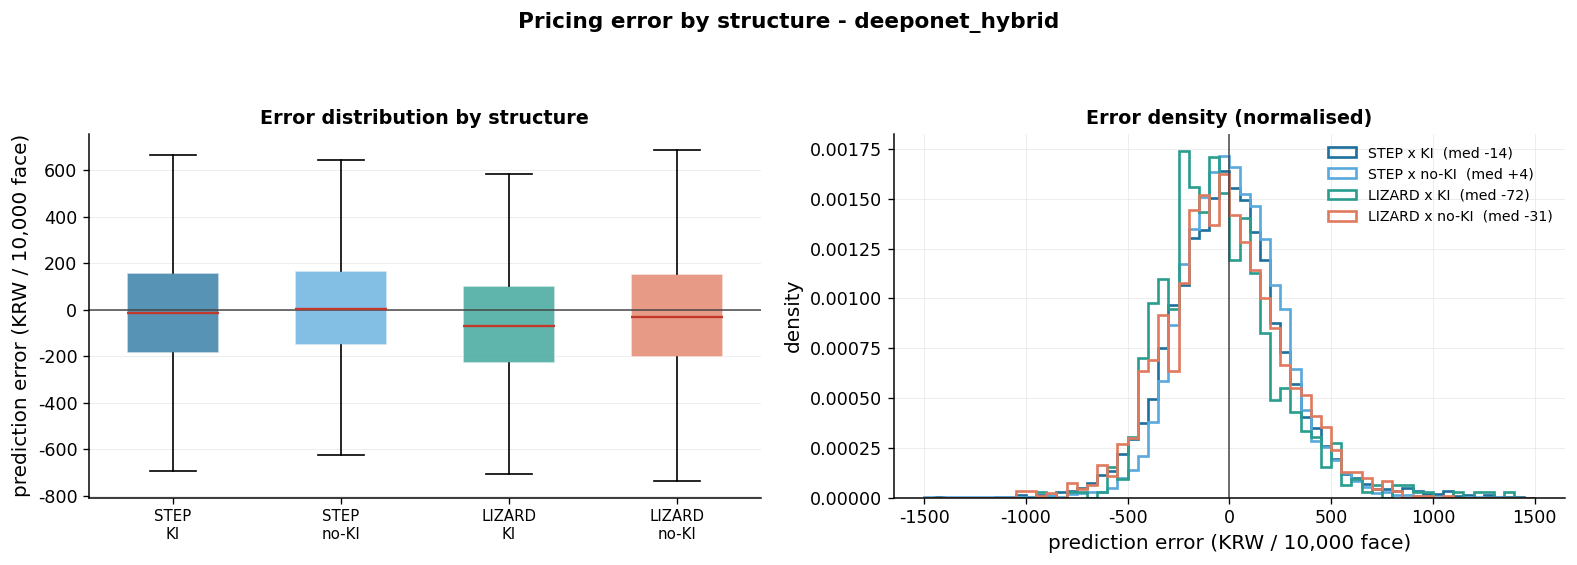

saved -> seg_structure_error.png


In [4]:
# 그림 3: 구조별 오차 분포 (원 단위) — 박스 + 개별 점 일부
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 4.8))
dat = [d[d.struct == s].err.values * FACE for s in STRUCTS]
bp = ax[0].boxplot(dat, vert=True, patch_artist=True, showfliers=False,
                   medianprops=dict(color="#c0392b", lw=1.4), widths=0.55)
for patch, c in zip(bp["boxes"], _plot._QUAL):
    patch.set_facecolor(c); patch.set_alpha(0.75); patch.set_edgecolor("white")
ax[0].axhline(0, color="#444", lw=0.9)
ax[0].set_xticklabels([s.replace(" x ", "\n") for s in STRUCTS], fontsize=9)
ax[0].set_ylabel("prediction error (KRW / 10,000 face)")
ax[0].set_title("Error distribution by structure", fontsize=11.5)
ax[0].grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)

for j, s in enumerate(STRUCTS):
    e = d[d.struct == s].err.values * FACE
    ax[1].hist(e, bins=60, range=(-1500, 1500), histtype="step", linewidth=1.6,
               color=_plot._QUAL[j], label=f"{s}  (med {np.median(e):+.0f})", density=True)
ax[1].axvline(0, color="#444", lw=0.9)
ax[1].set_xlabel("prediction error (KRW / 10,000 face)"); ax[1].set_ylabel("density")
ax[1].set_title("Error density (normalised)", fontsize=11.5)
ax[1].legend(fontsize=8.5); ax[1].grid(color="#dddddd", lw=0.5, alpha=0.6)

fig.suptitle(f"Pricing error by structure - {BEST}", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(fm.image("seg_structure_error"))
plt.show()
print("saved ->", fm.image("seg_structure_error").name)

## 5-2. 기초자산별 성능

바스켓 **조합**(3개 묶음)과 **개별 지수 포함 여부**를 나눠서 본다. 후자는 한 상품이 3개 지수에
각각 계상되므로 합계가 표본 수를 넘는다 — "그 지수가 들어간 상품의 성능"으로 읽어야 한다.

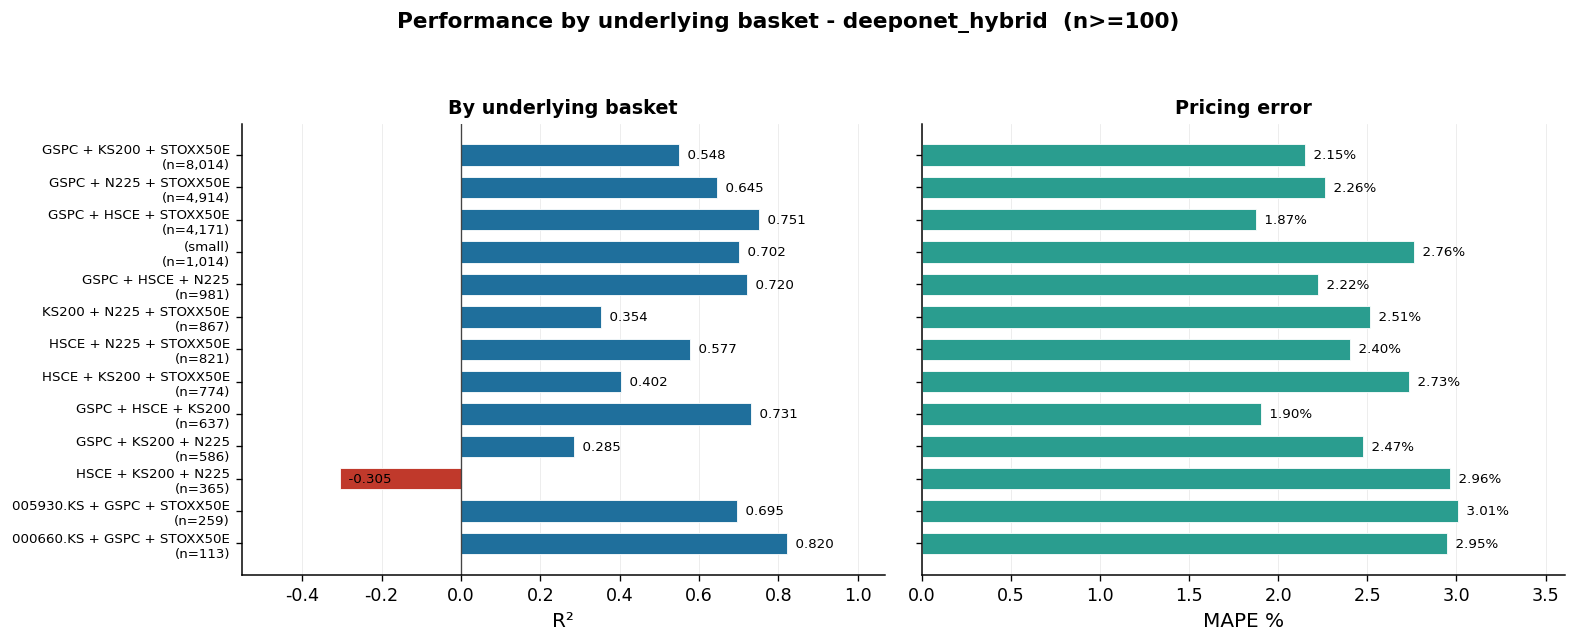

                              n      R2   MAPE%   Bias%
^GSPC|^KS200|^STOXX50E     8014  0.5482  2.1482  0.2453
^GSPC|^N225|^STOXX50E      4914  0.6448  2.2619  0.4151
^GSPC|^HSCE|^STOXX50E      4171  0.7514  1.8746  0.2159
(small)                    1014  0.7016  2.7591 -0.5103
^GSPC|^HSCE|^N225           981  0.7197  2.2238  0.0603
^KS200|^N225|^STOXX50E      867  0.3541  2.5118 -0.7063
^HSCE|^N225|^STOXX50E       821  0.5772  2.4048 -1.2399
^HSCE|^KS200|^STOXX50E      774  0.4025  2.7310 -0.5482
^GSPC|^HSCE|^KS200          637  0.7315  1.9040 -0.8688
^GSPC|^KS200|^N225          586  0.2848  2.4749 -0.7987
^HSCE|^KS200|^N225          365 -0.3048  2.9618 -0.6346
005930.KS|^GSPC|^STOXX50E   259  0.6954  3.0084  1.6945
000660.KS|^GSPC|^STOXX50E   113  0.8203  2.9488  1.6496
saved -> seg_underlying_basket.png


In [5]:
# 그림 4: 바스켓 조합별 R² · MAPE (표본 100건 이상)
BU = {name: metrics_by(M[M.model == name].y_true, M[M.model == name].y_pred,
                       M[M.model == name].udl_key, min_n=100) for name in MODELS}
pd.concat(BU, names=["model", "group"]).to_csv(fm.stat("seg_underlying_basket"))
U = BU[BEST].sort_values("n", ascending=False)
lab = [f"{i.replace('^','').replace('|',' + ')[:34]}\n(n={int(v):,})" for i, v in zip(U.index, U["n"])]

fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, max(4.6, 0.42 * len(U))))
y = np.arange(len(U))
cols = ["#c0392b" if r < 0 else "#1f6f9c" for r in U["R2"]]
ax[0].barh(y, U["R2"].values, height=0.66, color=cols, edgecolor="white", linewidth=0.5)
ax[0].set_yticks(y); ax[0].set_yticklabels(lab, fontsize=8); ax[0].invert_yaxis()
ax[0].axvline(0, color="#444", lw=0.8)
for i, v in enumerate(U["R2"].values):
    ax[0].text(v, i, f"  {v:.3f}", va="center", fontsize=8)
ax[0].set_xlabel("R²"); ax[0].set_title("By underlying basket", fontsize=11.5)
ax[0].grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6); ax[0].margins(x=0.22)

ax[1].barh(y, U["MAPE%"].values, height=0.66, color="#2a9d8f", edgecolor="white", linewidth=0.5)
ax[1].set_yticks(y); ax[1].set_yticklabels([]); ax[1].invert_yaxis()
for i, v in enumerate(U["MAPE%"].values):
    ax[1].text(v, i, f"  {v:.2f}%", va="center", fontsize=8)
ax[1].set_xlabel("MAPE %"); ax[1].set_title("Pricing error", fontsize=11.5)
ax[1].grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6); ax[1].margins(x=0.20)

fig.suptitle(f"Performance by underlying basket - {BEST}  (n>=100)", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(fm.image("seg_underlying_basket"))
plt.show()
print(U[["n", "R2", "MAPE%", "Bias%"]].round(4).to_string())
print("saved ->", fm.image("seg_underlying_basket").name)

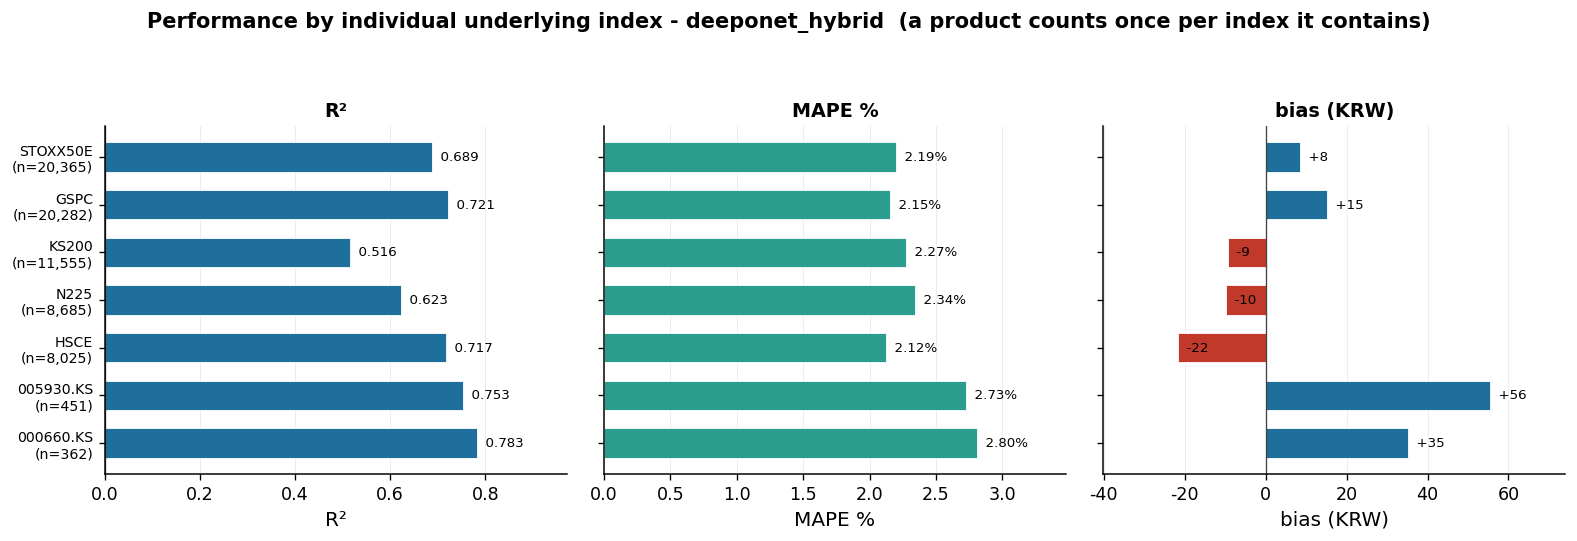

   ticker     n     R2   MAPE    BiasKRW
^STOXX50E 20365 0.6888 2.1950   8.470500
    ^GSPC 20282 0.7206 2.1516  15.174900
   ^KS200 11555 0.5162 2.2746  -9.353500
    ^N225  8685 0.6229 2.3443  -9.801800
    ^HSCE  8025 0.7168 2.1205 -21.594299
005930.KS   451 0.7529 2.7281  55.501701
000660.KS   362 0.7830 2.8046  35.205601
saved -> seg_underlying_ticker.png


In [6]:
# 그림 5: 개별 지수 포함 여부별 성능 (한 상품이 3개 지수에 계상됨)
def by_ticker(d, min_n=200):
    tk = pd.unique(pd.concat([d.udl1, d.udl2, d.udl3]).dropna())
    out = []
    for t in tk:
        g = d[(d.udl1 == t) | (d.udl2 == t) | (d.udl3 == t)]
        if len(g) < min_n:
            continue
        out.append(dict(ticker=t, n=len(g), R2=r2_score(g.y_true, g.y_pred),
                        MAPE=g.ape.mean(), BiasKRW=g.err.mean() * FACE))
    return pd.DataFrame(out).sort_values("n", ascending=False).reset_index(drop=True)

T = by_ticker(M[M.model == BEST])
Tall = pd.concat({name: by_ticker(M[M.model == name]) for name in MODELS}, names=["model", "i"])
Tall.to_csv(fm.stat("seg_underlying_ticker"))

fig, ax = plt.subplots(1, 3, figsize=(_plot.SLIDE_W, max(4.6, 0.46 * len(T))))
y = np.arange(len(T))
names = [f"{t.replace('^','')}\n(n={int(nn):,})" for t, nn in zip(T.ticker, T.n)]
for a, col, lab, base in [(ax[0], "R2", "R²", 0.0), (ax[1], "MAPE", "MAPE %", None),
                          (ax[2], "BiasKRW", "bias (KRW)", 0.0)]:
    v = T[col].values
    c = ["#c0392b" if (base is not None and x < base) else "#1f6f9c" for x in v] if base is not None else "#2a9d8f"
    a.barh(y, v, height=0.62, color=c, edgecolor="white", linewidth=0.5)
    a.set_yticks(y); a.set_yticklabels(names if a is ax[0] else [], fontsize=8.5)
    a.invert_yaxis()
    if base is not None:
        a.axvline(0, color="#444", lw=0.8)
    fmt = "{:.3f}" if col == "R2" else ("{:.2f}%" if col == "MAPE" else "{:+.0f}")
    for i, x in enumerate(v):
        a.text(x, i, "  " + fmt.format(x), va="center", fontsize=8)
    a.set_xlabel(lab); a.set_title(lab, fontsize=11.5)
    a.grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6); a.margins(x=0.24)
fig.suptitle(f"Performance by individual underlying index - {BEST}"
             "  (a product counts once per index it contains)", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(fm.image("seg_underlying_ticker"))
plt.show()
print(T.round(4).to_string(index=False))
print("saved ->", fm.image("seg_underlying_ticker").name)

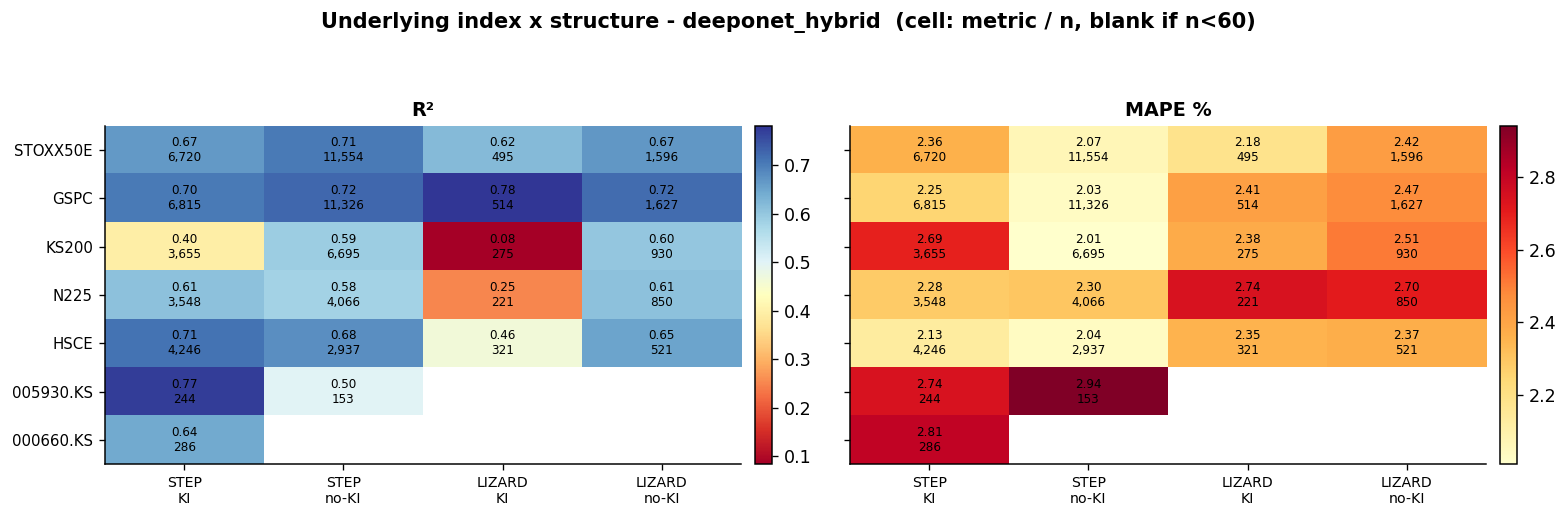

saved -> seg_underlying_x_structure.png


In [7]:
# 그림 6: 지수 × 구조 히트맵 (R² 와 MAPE%)
TK = list(T.ticker)
H_r2 = np.full((len(TK), len(STRUCTS)), np.nan)
H_mp = np.full((len(TK), len(STRUCTS)), np.nan)
H_n = np.zeros((len(TK), len(STRUCTS)), int)
for i, t in enumerate(TK):
    for j, s in enumerate(STRUCTS):
        g = d[(d.struct == s) & ((d.udl1 == t) | (d.udl2 == t) | (d.udl3 == t))]
        H_n[i, j] = len(g)
        if len(g) >= 60:
            H_r2[i, j] = r2_score(g.y_true, g.y_pred); H_mp[i, j] = g.ape.mean()

fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, max(4.4, 0.5 * len(TK))))
for a, H, lab, cmap in [(ax[0], H_r2, "R²", "RdYlBu"), (ax[1], H_mp, "MAPE %", "YlOrRd")]:
    im = a.imshow(H, aspect="auto", cmap=cmap)
    a.set_xticks(range(len(STRUCTS)))
    a.set_xticklabels([s.replace(" x ", "\n") for s in STRUCTS], fontsize=8.5)
    a.set_yticks(range(len(TK)))
    a.set_yticklabels([t.replace("^", "") for t in TK] if a is ax[0] else [], fontsize=9)
    for i in range(len(TK)):
        for j in range(len(STRUCTS)):
            if not np.isnan(H[i, j]):
                a.text(j, i, f"{H[i,j]:.2f}\n{H_n[i,j]:,}", ha="center", va="center", fontsize=7.2)
    a.set_title(lab, fontsize=11.5)
    fig.colorbar(im, ax=a, fraction=0.046, pad=0.02)
fig.suptitle(f"Underlying index x structure - {BEST}  (cell: metric / n, blank if n<60)",
             fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(fm.image("seg_underlying_x_structure"))
plt.show()
print("saved ->", fm.image("seg_underlying_x_structure").name)

## 5-3. 시기별 안정성 (walk-forward 폴드 × 구조)

폴드 0 은 train 이 가장 적고(60%) 그 test 구간이 HSCEI 급락 직전이라, 학습에 없던 국면으로
외삽하게 된다. 구조별로도 같은 패턴인지 확인한다.

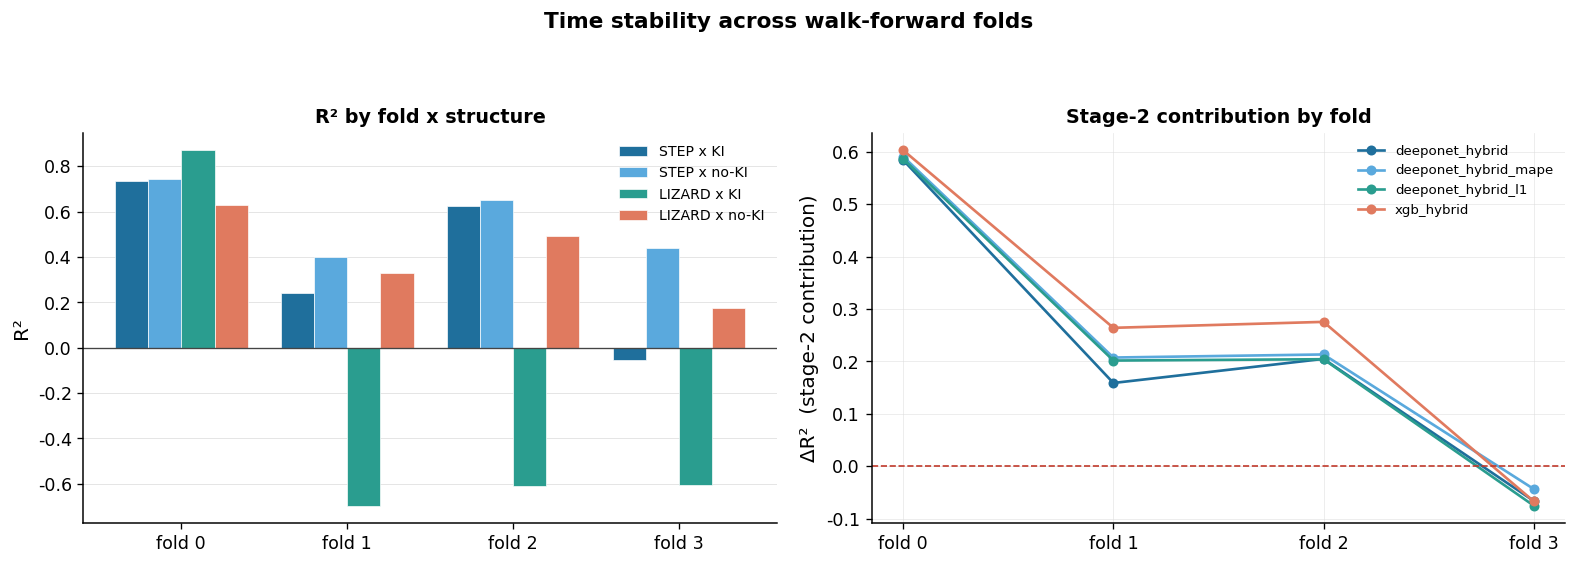

saved -> seg_fold_stability.png


In [8]:
# 그림 7: 폴드 × 구조 R² + stage2 기여
nf = len(D.WF)
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 4.8))
x = np.arange(nf); w = 0.8 / max(len(STRUCTS), 1)
for j, s in enumerate(STRUCTS):
    v, lb = [], []
    for k in range(nf):
        g = d[(d.struct == s) & (d.fold == k)]
        v.append(r2_score(g.y_true, g.y_pred) if len(g) > 30 else np.nan)
        lb.append(len(g))
    ax[0].bar(x + (j - (len(STRUCTS) - 1) / 2) * w, v, w, label=s,
              color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
ax[0].set_xticks(x); ax[0].set_xticklabels([f"fold {k}" for k in range(nf)])
ax[0].axhline(0, color="#444", lw=0.8); ax[0].set_ylabel("R²")
ax[0].set_title("R² by fold x structure", fontsize=11.5)
ax[0].legend(fontsize=8.5); ax[0].grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5)

# stage2 기여 = R2(최종) - R2(MC_hat + margin)
for j, name in enumerate(MODELS):
    dd = M[M.model == name]
    if "resid_pred" not in dd.columns or dd["resid_pred"].isna().all():
        continue
    con = []
    for k in range(nf):
        g = dd[dd.fold == k]
        base = g.y_pred - g.resid_pred
        con.append(r2_score(g.y_true, g.y_pred) - r2_score(g.y_true, base))
    ax[1].plot(x, con, "o-", lw=1.6, ms=5, color=_plot._QUAL[j % len(_plot._QUAL)], label=name)
ax[1].axhline(0, color="#c0392b", lw=1.0, ls="--")
ax[1].set_xticks(x); ax[1].set_xticklabels([f"fold {k}" for k in range(nf)])
ax[1].set_ylabel("ΔR²  (stage-2 contribution)")
ax[1].set_title("Stage-2 contribution by fold", fontsize=11.5)
ax[1].legend(fontsize=8); ax[1].grid(color="#dddddd", lw=0.5, alpha=0.6)

fig.suptitle("Time stability across walk-forward folds", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(fm.image("seg_fold_stability"))
plt.show()
print("saved ->", fm.image("seg_fold_stability").name)

## 5-4. 요약

In [9]:
# 요약 표 (구조 × 모델 R²) + 저장물 목록
piv = S.pivot(index="struct", columns="model", values="R2").reindex(STRUCTS).round(4)
print("=== 구조별 R² ===")
print(piv.to_string())
print("\n=== 기초자산 지수별 R² (대표 모델) ===")
print(T[["ticker", "n", "R2", "MAPE", "BiasKRW"]].round(4).to_string(index=False))
print("\nsaved images ->", [p.name for p in sorted(fm.IMAGE.glob("seg_*.png"))])
print("saved stats  ->", [p.name for p in sorted(fm.STAT.glob("seg_*.csv"))])

=== 구조별 R² ===
model           bench_xgboost  deeponet_hybrid  deeponet_hybrid_l1  deeponet_hybrid_mape  xgb_hybrid
struct                                                                                              
STEP x KI              0.1772           0.6610              0.6600                0.6646      0.6522
STEP x no-KI           0.4613           0.7041              0.7169                0.7184      0.7135
LIZARD x KI            0.2693           0.7632              0.7667                0.7572      0.7850
LIZARD x no-KI         0.2395           0.7047              0.7006                0.7086      0.6779

=== 기초자산 지수별 R² (대표 모델) ===
   ticker     n     R2   MAPE    BiasKRW
^STOXX50E 20365 0.6888 2.1950   8.470500
    ^GSPC 20282 0.7206 2.1516  15.174900
   ^KS200 11555 0.5162 2.2746  -9.353500
    ^N225  8685 0.6229 2.3443  -9.801800
    ^HSCE  8025 0.7168 2.1205 -21.594299
005930.KS   451 0.7529 2.7281  55.501701
000660.KS   362 0.7830 2.8046  35.205601

saved images -> ['seg